<a href="https://colab.research.google.com/github/akash360-coder/Demand-Forecasting-Inventory-Optimization/blob/main/AI%20Litigation%20%26%20Corporate%20Deception%20Risk%20Ledger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

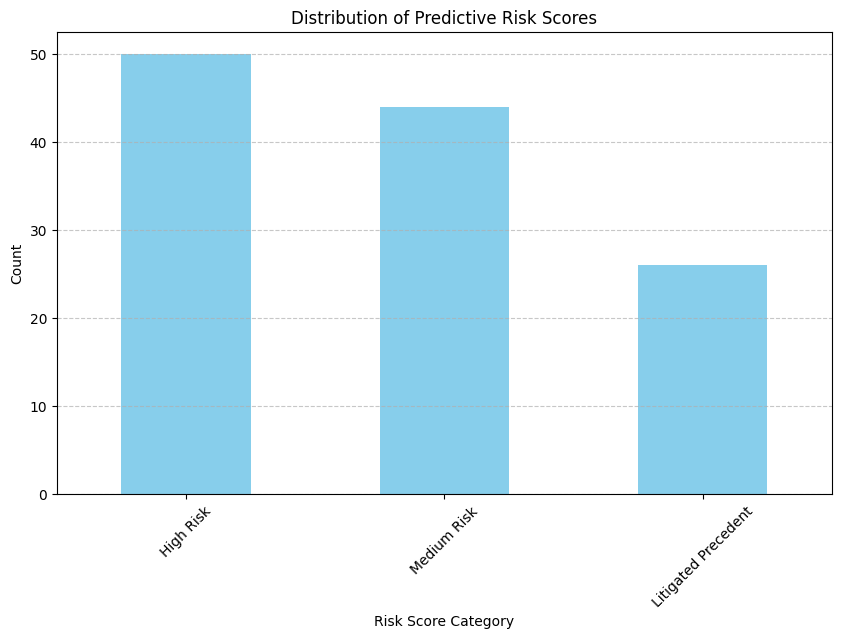

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/AI Litigation & Corporate Deception Risk Ledger.csv')

# Visualize the distribution of Predictive_Risk_Score
plt.figure(figsize=(10, 6))
df['Predictive_Risk_Score'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Predictive Risk Scores')
plt.xlabel('Risk Score Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Task 1 & 2: Data Cleaning and Additional EDA**

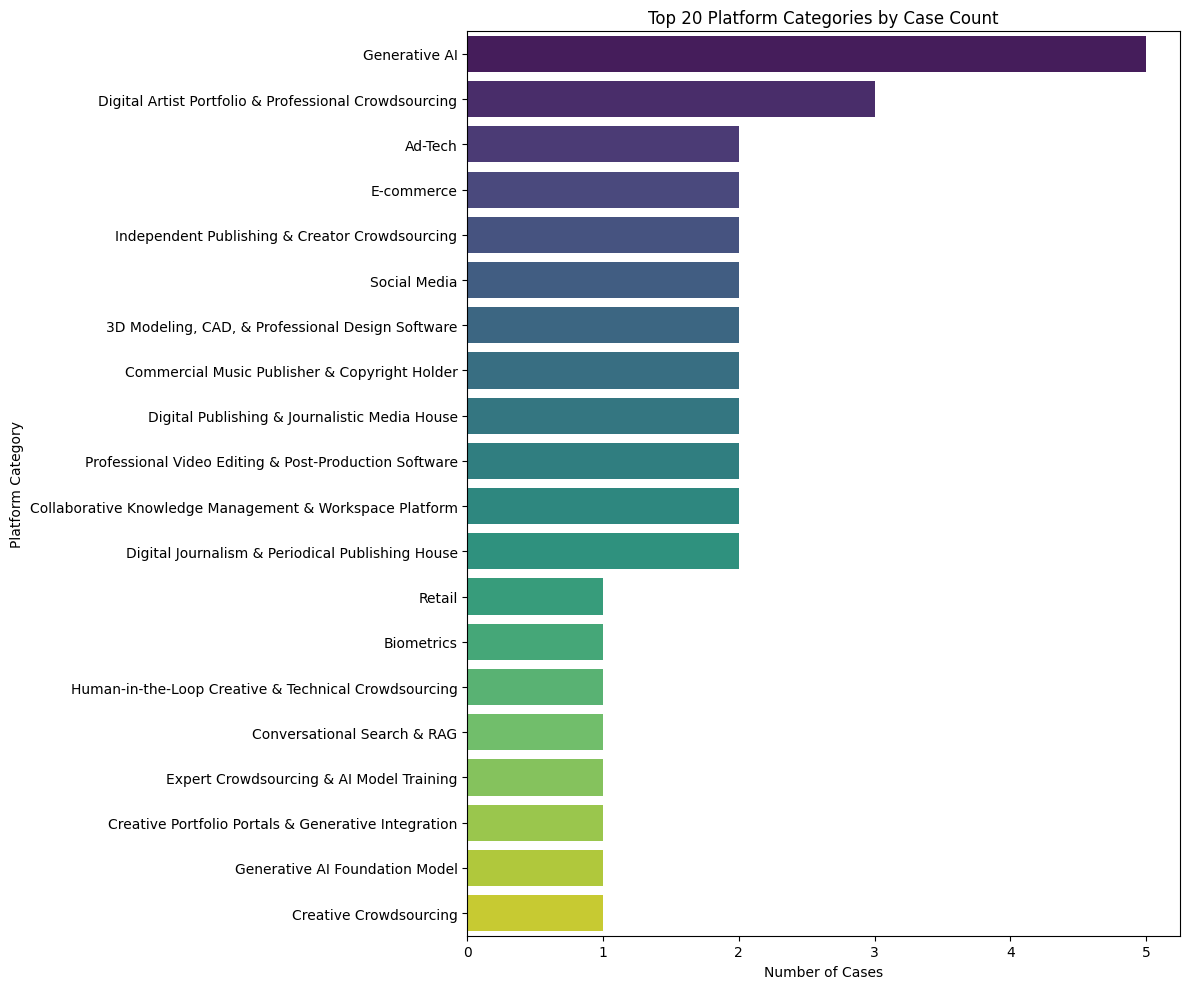

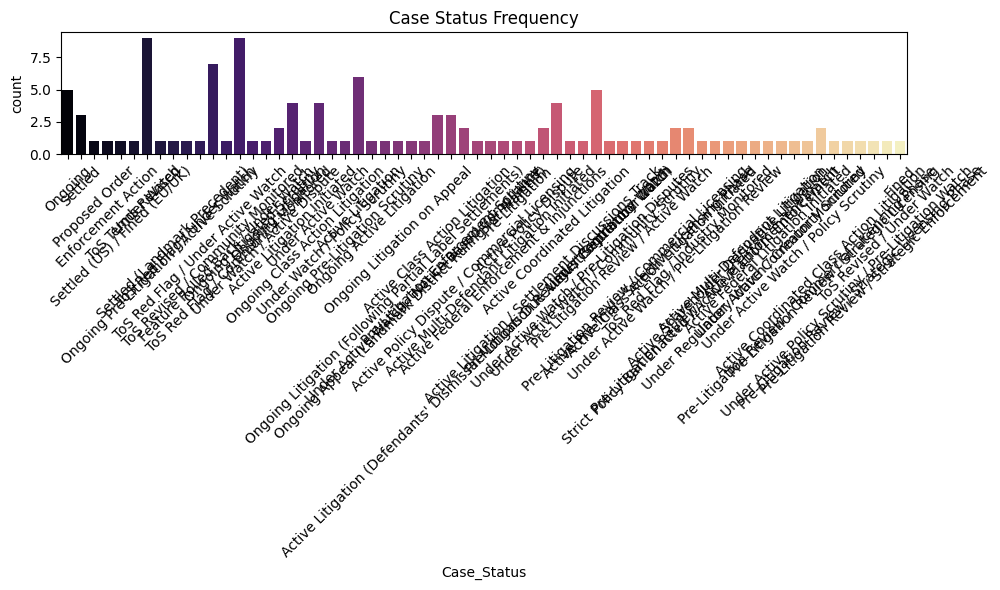

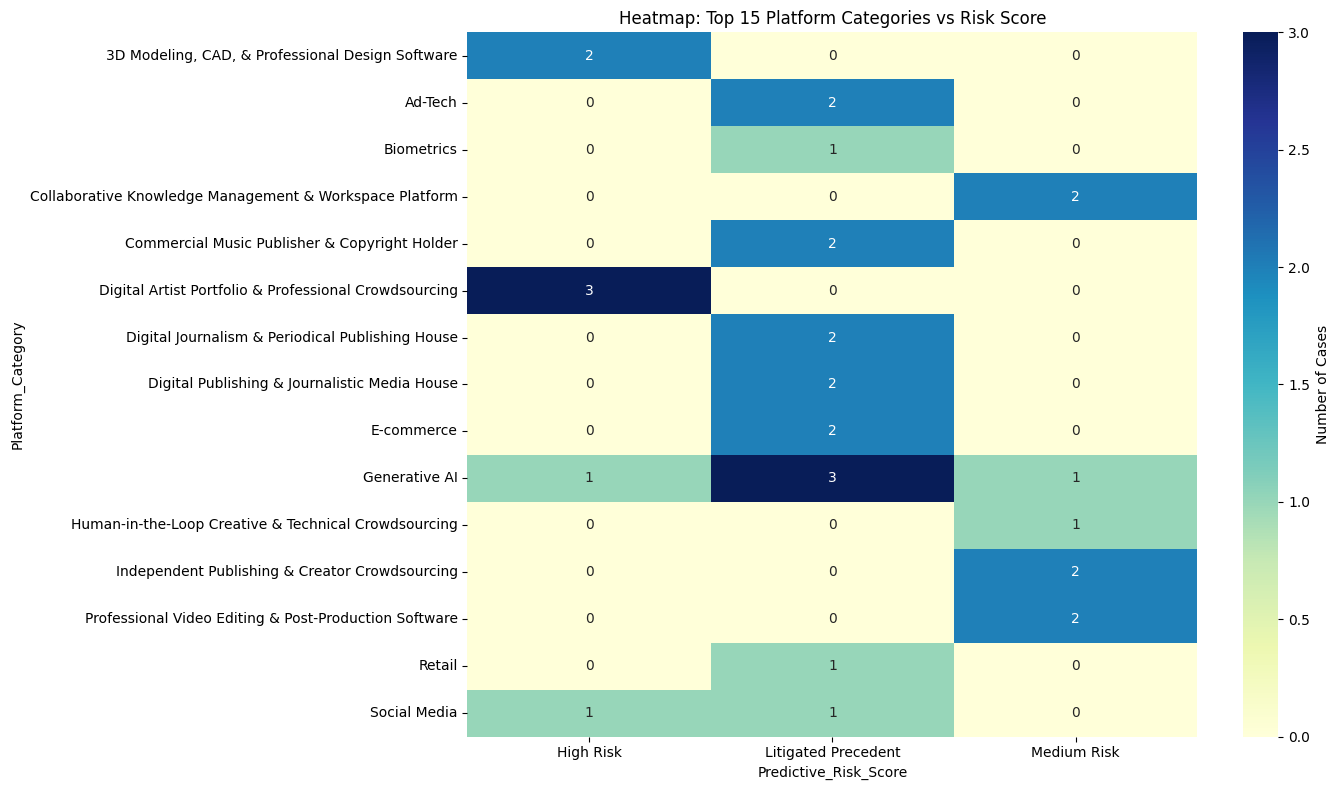

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Cleaning
df['Verified_Sources_and_Citations'] = df['Verified_Sources_and_Citations'].fillna('Not Provided')
df['Penalty_or_Settlement'] = df['Penalty_or_Settlement'].fillna('No Penalty/Settlement')

# 2. Improved EDA: Top 20 Platform Categories (Fixed Palette Warning)
plt.figure(figsize=(12, 10))
top_categories = df['Platform_Category'].value_counts().nlargest(20)
sns.barplot(y=top_categories.index, x=top_categories.values, hue=top_categories.index, palette='viridis', legend=False)
plt.title('Top 20 Platform Categories by Case Count')
plt.xlabel('Number of Cases')
plt.ylabel('Platform Category')
plt.tight_layout()
plt.show()

# Improved Case Status Distribution (Fixed Palette Warning)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Case_Status', palette='magma', hue='Case_Status', legend=False)
plt.title('Case Status Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Improved Heatmap (Reducing dimensions for clarity)
top_15_cats = df['Platform_Category'].value_counts().nlargest(15).index
filtered_df = df[df['Platform_Category'].isin(top_15_cats)]
crosstab = pd.crosstab(filtered_df['Platform_Category'], filtered_df['Predictive_Risk_Score'])

plt.figure(figsize=(14, 8))
sns.heatmap(crosstab, annot=True, cmap='YlGnBu', cbar_kws={'label': 'Number of Cases'})
plt.title('Heatmap: Top 15 Platform Categories vs Risk Score')
plt.tight_layout()
plt.show()

### **Task 3 & 4: NLP Preparation and Machine Learning Classification**

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 3. Feature Engineering (NLP)
df['Text_Features'] = df['Core_Issue'].astype(str) + " " + df['Deceptive_Practice_Mechanism'].astype(str)

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X = tfidf.fit_transform(df['Text_Features'])
y = df['Predictive_Risk_Score']

# 4. Machine Learning Model (Classification)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Machine Learning Classification Report:")
print(classification_report(y_test, y_pred))

Machine Learning Classification Report:
                     precision    recall  f1-score   support

          High Risk       0.62      0.80      0.70        10
Litigated Precedent       0.60      0.60      0.60         5
        Medium Risk       0.50      0.33      0.40         9

           accuracy                           0.58        24
          macro avg       0.57      0.58      0.57        24
       weighted avg       0.57      0.58      0.56        24

